In [22]:
# pylint: disable=import-error
# pylint: disable=wrong-import-position
"""
title: real_daily_climate_exp
author: José Javier Alonso Ramos
email: jjalonso@ugr.es
institution: DaSCI - UGR

Description:
Performs a real experiment with a daily_climate dataset.
The experiment consists of generating a daily_climate dataset with a polinomial function and
adding Gaussian noise to it. Then, a neural network model is trained to predict the target
variable. Finally, the gradients are used to reduce the noise in the data.
"""

# Libraries & Global variables #
# ------------------------------------------------------------------------------------------------ #
# Public libraries
import os
import sys
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader

# Seed
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'time_series', 'real', 'daily_climate')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints', 'time_series', 'real', 'daily_climate')
OUT_PATH = os.path.join(CURRENT_DIR, 'out', 'time_series', 'real', 'daily_climate')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING_PRE_XAI = True
FORCE_TRAINING_NN = True
FORCE_TRAINING_POST_XAI = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'
IS_TS = True

# Local libraries
from dataset import SlidingWindowDataset
from models import Trainer, LSTMModel
from utils import symmetric_mean_absolute_percentage_error

# Make sure that the GPU is being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"


# Functions definition #
# ------------------------------------------------------------------------------------------------ #
def dictionary_arrays_to_list(array_d:dict):
    """
    Run through a array_d dictionary converting its arrays to lists.

    Args:
        array_d (dict): dictionary which arrays we want to convert to lists.

    Returns:
        dict: dictionary with lists intead of arrays.
    """
    if isinstance(array_d, dict):
        return {k: dictionary_arrays_to_list(v) for k, v in array_d.items()}
    elif isinstance(array_d, np.ndarray):
        return array_d.tolist()
    else:
        return array_d


In [23]:
## Load the data ##
## ------------------------------------------------------------------------------------------ ##
df_data = pd.read_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    )
)

df_data.rename(columns={"meantemp": "y"}, inplace=True)

# scale the data
scaler = MinMaxScaler()
df_data = pd.DataFrame(scaler.fit_transform(df_data.values), columns=df_data.columns)

# assert there is no more categorical variables
columnas_categoricas = df_data.select_dtypes(include=['object', 'category']).columns
assert not list(columnas_categoricas)

# divide the data into train/test datasets
input_vars = df_data.columns

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    df_data[input_vars], df_data['y'], test_size=0.2, shuffle=False
)

In [24]:
df_data

,y,humidity,wind_speed,meanpressure
0,0.122271,0.820957,0.000000,0.132603
1,0.042795,0.907591,0.070583,0.132881
2,0.035662,0.849835,0.109743,0.132994
3,0.081514,0.668867,0.029212,0.132799
4,0.000000,0.847910,0.087636,0.132712
...,...,...,...,...
1571,0.871179,0.162541,0.131750,0.130385
1572,0.863537,0.299711,0.164910,0.130548
1573,0.822271,0.317327,0.210564,0.130772
1574,0.821507,0.162541,0.235966,0.130841


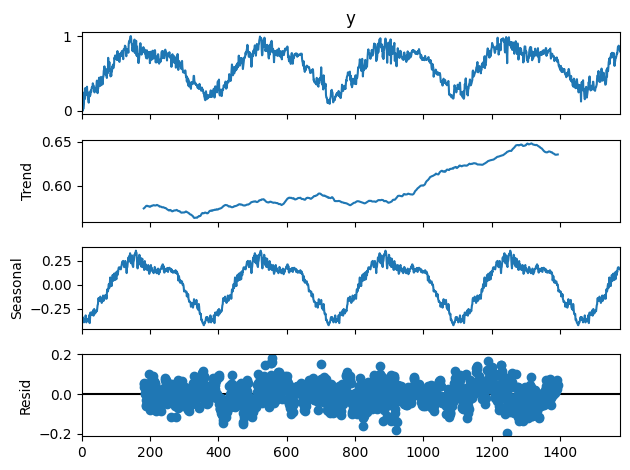

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_data['y'], model='additive', period=365)
result.plot()
plt.show()

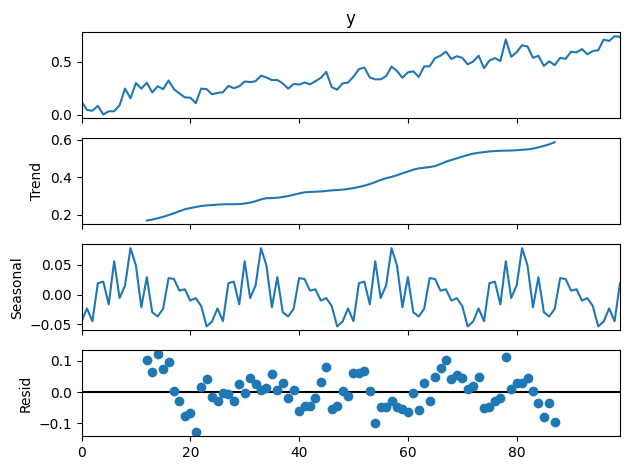

In [26]:
result = seasonal_decompose(df_data['y'][:100], model='additive', period=24)
result.plot()
plt.show()

In [27]:
## Declare a Neural Network model and prepare the data to train it ##
## ------------------------------------------------------------------------------------------ ##
# Create the dataloaders
batch_size = 64
window_size = 30
train_dataset = SlidingWindowDataset(
    X_train_orig,
    y_train_orig,
    window_size=window_size,
    future=1
)
val_dataset = SlidingWindowDataset(
    X_test_orig,
    y_test_orig,
    window_size=window_size,
    future=1
)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Create Neural Network model
input_size = X_train_orig.shape[1] # Número de variables de entrada
hidden_size = 512  # Número de neuronas en la capa oculta
output_size = 1  # Predicción de una variable
num_layers = 1  # Número de capas LSTM
model = LSTMModel(input_size, hidden_size, output_size, num_layers).to(device)

# Set model parameters and create the model Trainer object
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
denoiser_checkpoint_path = os.path.join(
    CHECKPOINT_PATH,
    'orig',
    'nn_orig.pth'
)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=denoiser_checkpoint_path
)


In [32]:
for x, y in train_dataset:
    print(x, y)
    break

[[0.12227074 0.8209571  0.         0.13260331]
 [0.04279476 0.90759076 0.07058266 0.132881  ]
 [0.0356623  0.84983498 0.10974262 0.13299381]
 [0.08151383 0.66886689 0.02921206 0.13279856]
 [0.         0.84790979 0.08763619 0.13271178]
 [0.03056769 0.80132013 0.03505448 0.13290703]
 [0.03056769 0.75280528 0.14921838 0.13316737]
 [0.08733624 0.58085809 0.16918184 0.13300001]
 [0.24454148 0.43688119 0.29606821 0.13277686]
 [0.15283843 0.56105611 0.17527238 0.13260331]
 [0.29694323 0.43729373 0.25038912 0.13266529]
 [0.24454148 0.69966997 0.31332476 0.13259091]
 [0.30058224 0.71314631 0.10974262 0.13229958]
 [0.20887918 0.86331133 0.01460603 0.13253822]
 [0.26637555 0.67491749 0.01251946 0.1326281 ]
 [0.23944687 0.8459846  0.         0.13273348]
 [0.3209607  0.77860286 0.12434865 0.132625  ]
 [0.23944687 0.90951595 0.21198484 0.13245144]
 [0.19868996 0.73047305 0.13934944 0.13338432]
 [0.16157205 0.71452145 0.20064966 0.13320456]
 [0.15895197 0.73432343 0.05258171 0.13329754]
 [0.1069869  

In [28]:

## Train the Neural Network or load its weights from a checkpoint ##
## -------------------------------------------------------------------------------------- ##
if os.path.exists(denoiser_checkpoint_path) and not FORCE_TRAINING_NN:
    model.load_state_dict(torch.load(denoiser_checkpoint_path))
    if VERBOSE:
        print(
            'Checkpoint loaded for the neural network model from path: ',
            denoiser_checkpoint_path
        )
else:
    model, _, _, _, _ = trainer_basic.fit(verbose=VERBOSE)


Training is started!


Epochs loop:  23%|██▎       | 115/500 [00:39<02:13,  2.88epoch/s, Train loss: 0.0025]

Training stopped as validation loss did not improve for 15 epochs.


In [30]:

## Predict and get the metrics for de NN model ##
## -------------------------------------------------------------------------------------- ##
predictions_test = trainer_basic.eval_dataloader(val_dataloader)
y_pred_test = np.array([y.cpu().detach().numpy() for x in predictions_test for y in x])

# Show the metrics
gt_values = y_test_orig[window_size:]
predicted_values = y_pred_test
mae = mean_absolute_error(gt_values, predicted_values)
smape = symmetric_mean_absolute_percentage_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
r_squared = r2_score(gt_values, predicted_values)

nn_metrics = {
    'mse': mse,
    'rmse': rmse,
    'mae': mae,
    'smape': smape,
    'R2': r_squared
}

nn_metrics

/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/torch/nn/modules/rnn.py:1123: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:1410.)
  result = _VF.lstm(


{'mse': 0.002528226142792926,
 'rmse': 0.050281469178942315,
 'mae': 0.039534001220080696,
 'smape': 40.32958474609959,
 'R2': 0.9339816767264889}

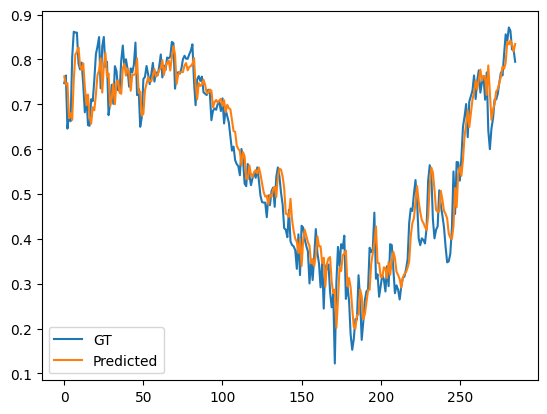

In [31]:
plt.plot(range(len(predicted_values)), y_test_orig[window_size:], label='GT')
plt.plot(range(len(predicted_values)), predicted_values, label='Predicted')
plt.legend()